# Fast inverse-Gaussian quantile for Schadner's implied volatility

Schadner's explicit formula (arXiv:2604.24480) turns Black-Scholes implied volatility into one inverse-Gaussian quantile, so there is no root-finding loop around the pricer. The quantile still has to be computed, and `scipy.stats.invgauss.ppf` was taking 34 ms of the 41 ms our vectorized notebook needed for 17,966 SPX options. This notebook summarizes the work to replace it.

The result is a solver that reads a 19 KB seed table and takes one Halley step. On the real data its maximum relative error is 2.5e-13 in a 60-row check against 50-digit arithmetic (section 6). It runs at about 44 ns per row in C++, about 40 times faster than the scipy call it replaces. The paper reports 59 ns per evaluation on a different CPU and a different, larger workload, so those numbers are close in size but are not a like-for-like comparison.

The notebook runs top to bottom from this folder and recomputes every number it shows. Sections:

1. The result
2. How the solver works
3. The table seed
4. Newton versus Halley
5. How we got here
6. Accuracy against an independent reference
7. Open items and how to rerun

Files in `quantile_solver/`

| File | Role |
|---|---|
| `ig_quantile.py` | Python reference solver, table seed, benchmark |
| `ig_quantile.hpp` | Header-only C++ port |
| `ig_table.h` | The seed table, generated from the Python module |
| `bench.cpp` | C++ benchmark and accuracy harness |
| `gen_reference.py` | Writes `reference.csv`, `edge.csv` and `ig_table.h` |
| `mp_truth.py` | 50-digit mpmath quantile used as ground truth |
| `test_ig_quantile.py`, `test_table_edges.cpp` | Regression tests |


In [1]:
import subprocess
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.stats import invgauss

import ig_quantile as q
import mp_truth

warnings.simplefilter("ignore")


def show(df, formats=None, index=True):
    """Render a DataFrame as an HTML table with per-column number formats (no jinja2 needed)."""
    out = df.copy()
    for col, fmt in (formats or {}).items():
        out[col] = out[col].map(fmt.format)
    display(HTML(out.to_html(index=index, escape=True, border=0)))


# Chart colors follow the validated reference palette (slots 1 and 2, light surface).
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "regular", "axes.titlelocation": "left",
    "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})

DATA_DIR = Path("..") / ".." / "fim500project" / "SPXIV-Surface" / "data"
DATA_DIR = (Path.cwd() / DATA_DIR).resolve()
price, spot, strike, t, rate, dividend = q._load_real_inputs(DATA_DIR)
s, mu = q.survival_inputs(price, spot, strike, t, rate, dividend)
finite = np.isfinite(mu)
clipped = s < 1.0001e-14
valid = finite & ~clipped

# Reference for error measurements: the analytic seed with 40 Newton steps. It shares the survival
# function's precision floor, so section 6 checks accuracy against mpmath as well.
x_ref = q.ig_quantile_survival(s, mu, n_iter=40, seed="analytic", halley=False)

print(f"{len(s):,} paired SPX options, {clipped.sum():,} of them clipped at s = 1e-14 "
      f"(quotes at or below intrinsic value), mu from {mu[finite].min():.2g} to {mu[finite].max():.2g}")


17,966 paired SPX options, 1,248 of them clipped at s = 1e-14 (quotes at or below intrinsic value), mu from 1.3 to 6.8e+06


## 1. The result

The table compares each approach on the same 17,966 rows. Times are the best of several runs of the whole array in Python, so they include NumPy overhead. The C++ timings in section 6 are the ones to compare against the paper. Error is the maximum relative error of the quantile against the reference, over the rows that are not clipped. The scipy row shows 2e-11 because scipy receives `p = 1 - s`, which has already rounded `s`. That is scipy's input precision, not a flaw in the reference.


In [2]:
def best_of(fn, repeats=15):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - start)
    return min(times), out

p = 1 - s
sec_scipy, x_scipy = best_of(lambda: invgauss.ppf(p, mu=mu))

configs = [
    ("scipy invgauss.ppf", None),
    ("analytic seed, 6 Newton steps", dict(seed="analytic", n_iter=6, halley=False)),
    ("table seed only", dict(n_iter=0)),
    ("table seed, 1 Newton step", dict(n_iter=1, halley=False)),
    ("table seed, 2 Newton steps", dict(n_iter=2, halley=False)),
    ("table seed, 1 Halley step", dict(n_iter=1, halley=True)),
]
rows = []
for name, kw in configs:
    if kw is None:
        sec, x = sec_scipy, x_scipy
    else:
        sec, x = best_of(lambda kw=kw: q.ig_quantile_survival(s, mu, **kw))
    err = np.abs(x / x_ref - 1)[valid].max()
    rows.append({"method": name, "ms": sec * 1e3, "ns per row": sec / len(s) * 1e9,
                 "x faster than scipy": sec_scipy / sec, "max relative error": err})
result = pd.DataFrame(rows).set_index("method")
show(result, {"ms": "{:.2f}", "ns per row": "{:.0f}", "x faster than scipy": "{:.1f}", "max relative error": "{:.1e}"})


,ms,ns per row,x faster than scipy,max relative error
method,,,,
scipy invgauss.ppf,33.96,1890,1.0,2.1e-11
"analytic seed, 6 Newton steps",2.84,158,12.0,2.1e-13
table seed only,1.45,81,23.3,3.5e-04
"table seed, 1 Newton step",1.95,108,17.4,1.2e-08
"table seed, 2 Newton steps",2.32,129,14.6,2.1e-13
"table seed, 1 Halley step",1.99,111,17.1,4.4e-13


Two things stand out. The table seed alone is already accurate to a few parts in ten thousand. And one Halley step turns that seed into an answer at the precision floor of the survival formula, while one Newton step stops near 1e-8. Sections 3 and 4 explain both.

## 2. How the solver works

For a call with log-moneyness `k = ln(K/F)`, Schadner's formula needs the quantile `x` of an inverse-Gaussian distribution with mean `mu = 2/|k|` and shape 1, and the implied volatility is `sigma = (2/sqrt(T)) / sqrt(x)`. The quantile solves `S(x; mu) = s`, where `s = 1 - p` comes from the normalized option price and `S` is the survival function

$$S(x;\mu) = \Phi(b-a) - e^{2/\mu}\,\Phi(-a-b), \qquad a = \sqrt{x}/\mu,\quad b = 1/\sqrt{x}.$$

The solver makes three choices that the data forces.

- **Work with `s`, not `p`.** On this data `p` is above 0.9 on every row, and 7% of rows have `s` pinned at the 1e-14 clip. Forming `s` as `1 - p` rounds it onto a grid of 1.1e-16, which is a large relative error when `s` is small. `survival_inputs` computes `s` directly. For out-of-the-money calls it equals the normalized price exactly.
- **Iterate on `y = ln x`.** The target is `ln S(e^y) = ln s`. The quantile spans five orders of magnitude on this data (x from about 60 to 5e5), and the survival function is close to a power law in `x` for large `mu` and close to exponential otherwise. In log space both regimes are far better behaved.
- **Start from a good seed.** A local method converges in a few steps only if it starts close. That is the job of the table in section 3.


## 3. The table seed

`ln x` is a smooth function of `(ln mu, ln s)`. It levels off in `ln mu` once `mu` is much larger than `sqrt(x)`, and bends once between the large-`mu` and exponential-tail regimes. A smooth function of two variables can be tabulated on a coarse grid and read back with local cubic interpolation. The grid spacing sets the seed accuracy, so the table size is a direct tuning knob.

The table covers `ln mu` in [0, 17] and `ln s` in [-33, -2] at spacing 0.5. The chart shows why that rectangle is the right size. The real rows sit in a band inside it, and the clipped rows form a separate row of points at `ln s` near -32.


table: 37 x 65 nodes, 18.8 KB, spacing 0.5 in both ln mu and ln s


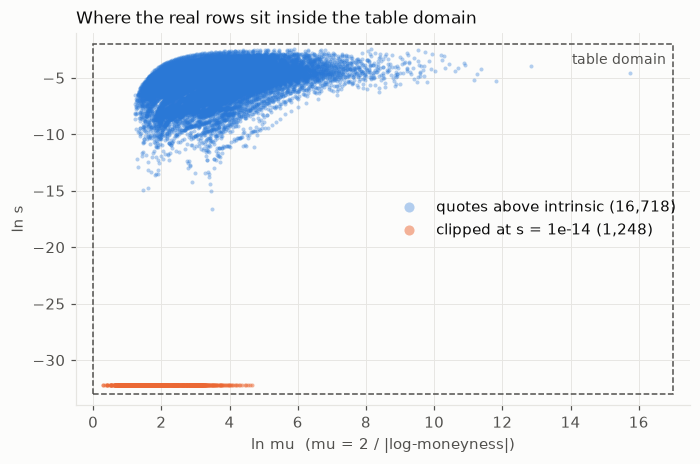

In [3]:
tbl = q._table()
print(f"table: {tbl.shape[0]} x {tbl.shape[1]} nodes, {tbl.nbytes / 1024:.1f} KB, spacing {q.TABLE_HU} in both ln mu and ln s")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
u, w = np.log(mu[finite]), np.log(s[finite])
ok = valid[finite]
ax.scatter(u[ok], w[ok], s=7, color=BLUE, alpha=0.35, linewidths=0, label=f"quotes above intrinsic ({ok.sum():,})")
ax.scatter(u[~ok], w[~ok], s=7, color=ORANGE, alpha=0.5, linewidths=0, label=f"clipped at s = 1e-14 ({(~ok).sum():,})")
ax.add_patch(plt.Rectangle((q.TABLE_U[0], q.TABLE_W[0]), q.TABLE_U[1] - q.TABLE_U[0], q.TABLE_W[1] - q.TABLE_W[0],
                           fill=False, ec=INK2, lw=1, ls="--"))
ax.text(q.TABLE_U[1] - 0.2, q.TABLE_W[1] - 0.8, "table domain", ha="right", va="top", color=INK2, fontsize=9)
ax.set_xlabel("ln mu  (mu = 2 / |log-moneyness|)")
ax.set_ylabel("ln s")
ax.set_title("Where the real rows sit inside the table domain")
ax.set_xlim(-0.5, 17.5)
ax.set_ylim(-34, -1)
ax.legend(loc="center right", markerscale=2.5)
plt.show()


The spacing is a trade between table size and seed accuracy. The next chart rebuilds the table at six spacings that keep every node inside `s < 1` and measures two errors on the real rows: the seed error alone, and the error after one Halley step. Coarser tables are cheaper but the Halley step can no longer clean up the seed. Finer tables gain nothing, because the Halley result already sits at the precision floor of the survival formula, about 2e-13 on this data. A spacing of 0.5 is the smallest table that reaches that floor.


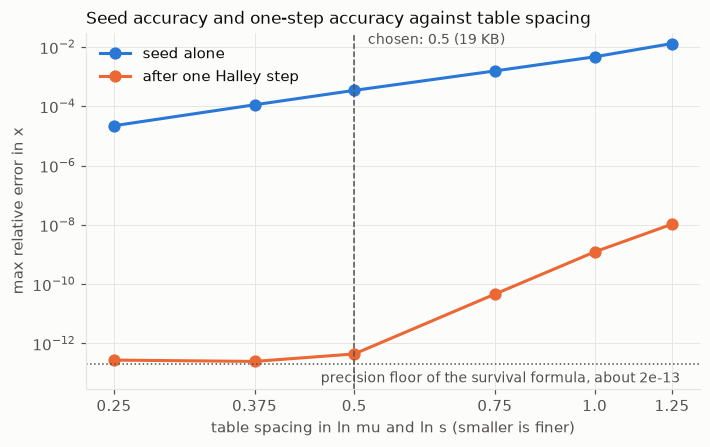

,KB,seed error,after 1 Halley step
spacing,,,
1.250,3.7,1.3e-02,1.1e-08
1.000,5.3,4.7e-03,1.2e-09
0.750,8.9,1.6e-03,4.6e-11
0.500,18.8,3.5e-04,4.4e-13
0.375,32.2,1.1e-04,2.5e-13
0.250,70.4,2.2e-05,2.8e-13


In [4]:
def table_for_spacing(h):
    cells_u = round((q.TABLE_U[1] - q.TABLE_U[0]) / h)
    cells_w = round((q.TABLE_W[1] - q.TABLE_W[0]) / h)
    gu, gw = np.meshgrid(q.TABLE_U[0] - h + h * np.arange(cells_u + 3),
                         q.TABLE_W[0] - h + h * np.arange(cells_w + 3), indexing="ij")
    m, ss = np.exp(gu), np.exp(gw)
    table = q._refine_log(np.log(q.ig_seed(ss, m)), ss, m, 40)
    # A spacing that does not divide the domain can push the top padding node above s = 1,
    # which has no quantile. Fail loudly instead of letting a NaN poison the interpolation.
    assert np.isfinite(table).all(), f"spacing {h} puts a table node outside s < 1"
    return table, cells_u, cells_w


def seed_from_table(table, h, ss, m):
    fu, fw = (np.log(m) - q.TABLE_U[0]) / h, (np.log(ss) - q.TABLE_W[0]) / h
    iu, iw = fu.astype(int), fw.astype(int)
    wu, ww = q._lagrange_weights(fu - iu), q._lagrange_weights(fw - iw)
    return sum(wu[a] * sum(ww[b] * table[iu + a, iw + b] for b in range(4)) for a in range(4))


sv, mv, xv = s[valid], mu[valid], x_ref[valid]
spacing_rows = []
for h in (1.25, 1.0, 0.75, 0.5, 0.375, 0.25):
    table, cu, cw = table_for_spacing(h)
    y0 = seed_from_table(table, h, sv, mv)
    y1 = q._refine_log(y0, sv, mv, 1, halley=True)
    spacing_rows.append({"spacing": h, "KB": table.nbytes / 1024,
                         "seed error": np.abs(np.exp(y0) / xv - 1).max(),
                         "after 1 Halley step": np.abs(np.exp(y1) / xv - 1).max()})
spacing = pd.DataFrame(spacing_rows).set_index("spacing")

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(spacing.index, spacing["seed error"], color=BLUE, lw=2, marker="o", ms=7, label="seed alone")
ax.plot(spacing.index, spacing["after 1 Halley step"], color=ORANGE, lw=2, marker="o", ms=7, label="after one Halley step")
ax.axhline(2e-13, color=INK2, lw=1, ls=":")
ax.text(1.28, 1.15e-13, "precision floor of the survival formula, about 2e-13", ha="right", va="top", color=INK2, fontsize=9)
ax.set_ylim(3e-14, 3e-2)
ax.axvline(0.5, color=INK2, lw=1, ls="--")
ax.text(0.52, 3e-2, "chosen: 0.5 (19 KB)", color=INK2, fontsize=9, va="top")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(spacing.index)
ax.set_xticklabels([str(v) for v in spacing.index])
ax.minorticks_off()
ax.set_xlabel("table spacing in ln mu and ln s (smaller is finer)")
ax.set_ylabel("max relative error in x")
ax.set_title("Seed accuracy and one-step accuracy against table spacing")
ax.legend(loc="upper left")
plt.show()
show(spacing, {"KB": "{:.1f}", "seed error": "{:.1e}", "after 1 Halley step": "{:.1e}"})


## 4. Newton versus Halley

Both methods refine `y` on `h(y) = ln S(e^y) - ln s`. Newton uses the first derivative. Halley adds the second, and converges cubically where Newton converges quadratically. With the seed error near 3e-4, that difference decides whether one step is enough.

With `f` the density, `g1 = dh/dy = -x f / S`, and `g2 = d²h/dy²`, the Halley update is

$$\Delta y = \frac{2\,h\,g_1}{2\,g_1^2 - h\,g_2}, \qquad g_2 = g_1 - \frac{x^2 f\,(\ln f)'}{S} - \left(\frac{x f}{S}\right)^2 .$$

The last term is minus `(f/S)²`. While exploring seeds I first wrote it with a plus sign. That bug made Halley behave like a damaged Newton, which led me to conclude wrongly that Halley was worse in log space, and I wrote that conclusion into a docstring. I caught the sign error while sizing a finer table, when one Halley step from a 6e-5 seed gave 3e-9 where cubic convergence should have given about 1e-12. The chart below measures the corrected formula. After the fix, one Halley step from the 0.5 table reaches 4e-13, and Newton needs two steps for the same accuracy.


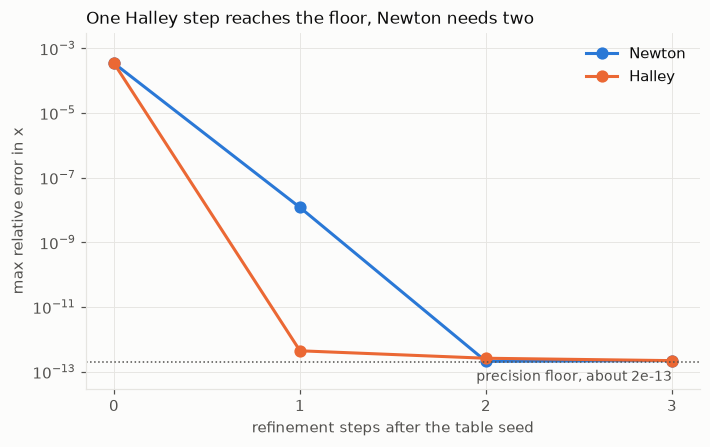

,Newton,Halley
steps,,
0,3.5e-04,3.5e-04
1,1.2e-08,4.4e-13
2,2.1e-13,2.6e-13
3,2.2e-13,2.2e-13


In [5]:
def error_after_steps(halley, max_steps=3):
    y = q.ig_seed_table(sv, mv)[0]
    errs = [np.abs(np.exp(y) / xv - 1).max()]
    for _ in range(max_steps):
        y = q._refine_log(y, sv, mv, 1, halley=halley)
        errs.append(np.abs(np.exp(y) / xv - 1).max())
    return errs

newton_errs, halley_errs = error_after_steps(False), error_after_steps(True)
steps = np.arange(len(newton_errs))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(steps, newton_errs, color=BLUE, lw=2, marker="o", ms=7, label="Newton")
ax.plot(steps, halley_errs, color=ORANGE, lw=2, marker="o", ms=7, label="Halley")
ax.axhline(2e-13, color=INK2, lw=1, ls=":")
ax.text(3.0, 1.15e-13, "precision floor, about 2e-13", ha="right", va="top", color=INK2, fontsize=9)
ax.set_ylim(3e-14, 3e-3)
ax.set_yscale("log")
ax.set_xticks(steps)
ax.set_xlabel("refinement steps after the table seed")
ax.set_ylabel("max relative error in x")
ax.set_title("One Halley step reaches the floor, Newton needs two")
ax.legend(loc="upper right")
plt.show()
show(pd.DataFrame({"Newton": newton_errs, "Halley": halley_errs}, index=pd.Index(steps, name="steps")), {"Newton": "{:.1e}", "Halley": "{:.1e}"})


## 5. How we got here

**Profile first.** The vectorized notebook took 41 ms. Splitting it by stage shows where the time was.


In [6]:
def prep_and_post():
    s_, mu_ = q.survival_inputs(price, spot, strike, t, rate, dividend)
    return (2.0 / np.sqrt(t)) / np.sqrt(np.ones_like(s_))

sec_ppf, _ = best_of(lambda: invgauss.ppf(p, mu=mu))
sec_rest, _ = best_of(prep_and_post)
profile = pd.DataFrame({"ms": [sec_ppf * 1e3, sec_rest * 1e3]}, index=["invgauss.ppf", "everything else in the formula"])
profile["share"] = profile["ms"] / profile["ms"].sum()
show(profile, {"ms": "{:.3f}", "share": "{:.1%}"})


,ms,share
invgauss.ppf,34.018,99.4%
everything else in the formula,0.208,0.6%


The quantile call was almost all of the time, so only a faster quantile could help. The rest of the formula is under 1% of the total, about 10 ns per row here, so it is already a small fraction of the paper's 59 ns.

**Attempts that did not work.** These are recorded so they are not tried again.

- *The notebook's ATM-limit seed.* `x = 1 / Phi^-1(1 - p/2)^2` is the exact limit as `mu` goes to infinity. For moderate `mu` and `p` near 1 it overshoots by orders of magnitude, the density underflows to exactly zero, Halley's step becomes 0/0, and the iteration freezes. Switching on a fixed `mu` threshold shrank the failures but never removed them.
- *A Gaussian-tail seed on its own.* Dropping the second survival term gives a closed form, but on this data it was off by a median factor of 5, because most rows sit in the transition regime where `x` is about `mu²`.
- *A single scaling ratio.* If `x / x_inf` depended only on `x_inf / mu²`, one curve would be enough. It does not. The spread in `ln x` reached about 0.9 across the real range, so the seed has to depend on both variables.
- *A fitted polynomial seed.* About 150 Chebyshev terms reached 0.2% error, and 49 terms still needed three Newton steps. That costs more than the Halley step it would save.
- *Minimum of the two analytic seeds.* This did work, and it is the fallback for off-table rows. The two limits overshoot in opposite regimes, so their minimum is always finite. It still needs about six Newton steps in log space, which is why a better seed was needed.
- *Mean-seeded Halley in `x` space.* The notebook `hand_rolled_seed_halley.ipynb` records this first attempt. Its closing cell lists which of its conclusions the final design supersedes.

**Python versus C++.** The table seed takes 79 ns per row in NumPy, as much as about three and a half Newton steps, because NumPy runs the 16 table lookups as separate array passes. The same lookup in C++ is 16 loads and a few multiplies. That is why the port was needed. In NumPy the table seed and the analytic seed cost about the same in total.


## 6. Accuracy against an independent reference

Comparing the solver with a reference built from the same survival function would hide any error that the function itself carries. So the check below solves each case in 50-digit arithmetic with mpmath, treating `s` and `mu` as exact. The first six cases are typical of the real data. The last six move toward the large-`mu`, small-`s` corner, where the survival function subtracts two nearly equal tail probabilities.


In [7]:
cases = [(35.0, 1e-4), (1.5, 0.05), (300.0, 1e-3), (3e3, 1e-6), (6.8e6, 1e-3), (50.0, 1e-8),
         (1e6, 1e-10), (2e7, 1e-14), (2e5, 1e-12), (3e8, 2e-10), (1e9, 1e-9), (0.5, 1e-3)]
rows = []
for m_, s_ in cases:
    x = float(q.ig_quantile_survival(np.array([s_]), np.array([m_]))[0])
    in_table = bool(q.ig_seed_table(np.array([s_]), np.array([m_]))[1][0])
    try:
        err = abs(float(x / mp_truth.quantile(s_, m_, x) - 1))
    except Exception as exc:
        err = np.nan
    rows.append({"mu": m_, "s": s_, "in table": in_table, "relative error vs mpmath": err})
accuracy = pd.DataFrame(rows)
show(accuracy, {"mu": "{:.3g}", "s": "{:.1e}", "relative error vs mpmath": "{:.1e}"}, index=False)


mu,s,in table,relative error vs mpmath
35,1.0e-04,True,1.4e-14
1.5,5.0e-02,True,1.8e-16
300,1.0e-03,True,2.0e-15
3e+03,1.0e-06,True,3.2e-12
6.8e+06,1.0e-03,True,8.1e-14
50,1.0e-08,True,2.3e-13
1e+06,1.0e-10,True,2.3e-09
2e+07,1.0e-14,True,9.3e-08
2e+05,1.0e-12,True,5.7e-11
3e+08,2.0e-10,False,5.8e-08


The first six cases are accurate to between 2e-16 and 3e-12, and the sample of real rows shows the typical real row is far better than that. The case at mu = 3e3, s = 1e-6 is the worst of the six and is not one of the real rows. The last six cases move into the corner, where the error is 1e-9 to 1e-7, and the C++ edge rows below reach 8e-7. More iterations do not help there, because the evaluation of `S` itself is only good to that level. It also means the exact-at-the-forward case needs separate handling. The solver returns the closed form there, which a test checks, but a quote within about 1e-7 of the forward is in the degraded region. Rows that close to the forward belong on the closed form `sigma = (2/sqrt(T)) Phi^-1((1+c)/2)`.

The C++ harness measures the same thing on 300 synthetic edge rows with mpmath references. It also prints the C++ timings. The cell compiles and runs `bench.cpp`, so it needs `clang++` on the path.


In [8]:
try:
    subprocess.run(["clang++", "-O3", "-march=native", "-std=c++17", "bench.cpp", "-o", "bench"], check=True,
                   capture_output=True, text=True)
    print(subprocess.run(["./bench"], check=True, capture_output=True, text=True).stdout)
except (FileNotFoundError, subprocess.CalledProcessError) as exc:
    print("could not build or run bench.cpp:", getattr(exc, "stderr", exc))


rows 17966
table seed + 0 Newton step(s):    0.184 ms    10.2 ns/row | rel err vs x_ref (port fidelity) 3.5e-04 | survival resid 7.2e-04
  (17966 rows in table domain, 0 on the fallback path)
table seed + 1 Newton step(s):    0.763 ms    42.5 ns/row | rel err vs x_ref (port fidelity) 1.2e-08 | survival resid 1.0e-08
table seed + 2 Newton step(s):    1.540 ms    85.7 ns/row | rel err vs x_ref (port fidelity) 2.1e-13 | survival resid 2.6e-11
table seed + 1 Halley step(s):    0.787 ms    43.8 ns/row | rel err vs x_ref (port fidelity) 4.4e-13 | survival resid 2.3e-11
table seed + 2 Halley step(s):    1.593 ms    88.6 ns/row | rel err vs x_ref (port fidelity) 2.3e-13 | survival resid 3.8e-11
log + table_seed only:    0.118 ms     6.6 ns/row
analytic seed + 6 steps: 16.167 ms   899.9 ns/row | rel err vs x_ref 2.2e-13
edge mu < 1     100 rows (100 off-table) | max rel err vs mpmath 8.0e-15
edge mu > e^17  100 rows (100 off-table) | max rel err vs mpmath 7.8e-07
edge s ~ 1e-14  100 rows (  0 o

In the output, "port fidelity" means the C++ result is compared with the Python module's result, which checks that the port reproduces it. Accuracy against truth is the mpmath comparison, shown on the `edge` lines above and in the table in this section. The `survival resid` column cannot rank methods, because it evaluates the same survival function and flattens at its floor.


The cell below applies the same check to 60 randomly chosen real rows that are not clipped, which is the evidence for the accuracy claim in section 1. It takes a few seconds because each row is solved in 50-digit arithmetic.

In [9]:
rng = np.random.default_rng(0)
idx = rng.choice(np.flatnonzero(valid), size=60, replace=False)
x_solver = q.ig_quantile_survival(s[idx], mu[idx])
errs = np.array([abs(float(xi / mp_truth.quantile(si, mi, xi) - 1)) for si, mi, xi in zip(s[idx], mu[idx], x_solver)])
display(Markdown(f"Relative error against mpmath on 60 random real rows, one Halley step from the table seed. "
                 f"Median {np.median(errs):.1e}, 90th percentile {np.quantile(errs, 0.9):.1e}, maximum {errs.max():.1e}."))


Relative error against mpmath on 60 random real rows, one Halley step from the table seed. Median 4.8e-15, 90th percentile 7.9e-14, maximum 2.5e-13.

## 7. Open items and how to rerun

**Open.**

- Report timing on shuffled rows with the median alongside the minimum, and report valid rows apart from the clipped ones, before quoting the C++ number against the paper.
- Route rows with `mu` above about 2e7 to the closed form. This should be accurate to roughly 1e-9 there, but I have not tested it. It matters only if other underlyings or a dense at-the-money grid are used.
- Replace the Newton `ndtri` in `ig_quantile.hpp` with a rational approximation if off-table inputs ever occur in production. It costs 900 ns per row on that path.
- Wire the C++ solver into the full IV pipeline, with the closed form at the forward, the no-arbitrage mask and the 100% IV cap, and compare end to end against `iv_inversion_schadner_explicit.ipynb`.

**Rerun.** From `quantile_solver/`:

```
python gen_reference.py                  # reference.csv, edge.csv, ig_table.h
python -m unittest -v                    # Python regression tests, mpmath ground truth
python ig_quantile.py                    # Python benchmark against scipy
clang++ -O1 -g -fsanitize=address,undefined -std=c++17 test_table_edges.cpp -o test_table_edges && ./test_table_edges
clang++ -O3 -march=native -std=c++17 bench.cpp -o bench && ./bench
```
